# Point Pattern Analysis - CVR Business Data

This notebook demonstrates point pattern analysis methods applied to CVR (Central Business Register) business location data from Copenhagen. 

The data contains spatiotemporal information about businesses, their locations, and their operational periods, enabling us to analyze how business distribution patterns have evolved over time.

###### Load some libraries

In [44]:
import pandas as pd  # tabular data in Python for data manipulation and analysis
import geopandas as gpd  # extension to Pandas to work with geospatial data
import os.path  # work with the local file system
from pathlib import Path  # modern path handling
from shapely.geometry import Point, Polygon, MultiPolygon  # work with vector geometries
import matplotlib as mpl  # plotting
from matplotlib import pyplot as plt  # matplotlib convenience functions
import numpy as np  # numerical operations
import seaborn as sns  # enhanced plotting

# Point pattern analysis libraries
import libpysal as ps
import pointpats
import pointpats.distance_statistics as dst
import pointpats.quadrat_statistics as qs
from pointpats import PointPattern, Window, as_window, PoissonPointProcess as csr
from libpysal.cg import Polygon as LPSPolygon

# Make figures larger
plt.rcParams['figure.figsize'] = [16, 16]

# Setup paths
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / 'data' / 'processed' / 'cvr'
CVR_GEOJSON = DATA_DIR / 'Cvr_certain_gentrified_industries.geojson'

print(f"Data path: {CVR_GEOJSON}")
print(f"File exists: {CVR_GEOJSON.exists()}")

Data path: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/cvr/Cvr_certain_gentrified_industries.geojson
File exists: True


#### Load CVR data

Let's load the CVR (Central Business Register) data from the GeoJSON file. This file contains business locations with temporal information about when they opened and closed (if applicable).

In [45]:
# Load CVR data from GeoJSON
cvr_gdf = gpd.read_file(CVR_GEOJSON)

print(f"Total CVR records: {len(cvr_gdf)}")
print(f"\nColumns: {list(cvr_gdf.columns)}")
print(f"\nFirst few records:")
print(cvr_gdf.head())

# Display data types
print(f"\nData types:")
print(cvr_gdf.dtypes)

Total CVR records: 9081

Columns: ['CVRNummer', 'navn', 'virksomhedStartdato', 'virksomhedOphoersdato', 'branche_kode', 'branche_navn', 'CVREnhedsId', 'Adresse', 'pNummer', 'tilknyttetVirksomhedsCVRNummer', 'produktionsenhedStartdato', 'produktionsenhedOphoersdato', 'geometry']

First few records:
   CVRNummer                              navn virksomhedStartdato  \
0   17890670  THE AUSTRALIAN BAR KØBENHAVN ApS          1994-07-01   
1   17890670  THE AUSTRALIAN BAR KØBENHAVN ApS          1994-07-01   
2   19047296                  A/S PSE NR. 4938          1996-01-01   
3   18204746                     RUE VERTE A/S          1994-11-07   
4   14234934                CAB INN ESTATE A/S          1990-05-15   

  virksomhedOphoersdato branche_kode  \
0                   NaT       563020   
1                   NaT       563020   
2                   NaT       477110   
3                   NaT       477110   
4            2008-07-09       552000   

                                       

#### Convert coordinates and visualize

First, let's plot all the CVR business locations:


Date columns info:
virksomhedStartdato - unique values: 3532
virksomhedStartdato - null values: 632

Start year range: 1987 to 2026
End year range: 1999.0 to 2026.0


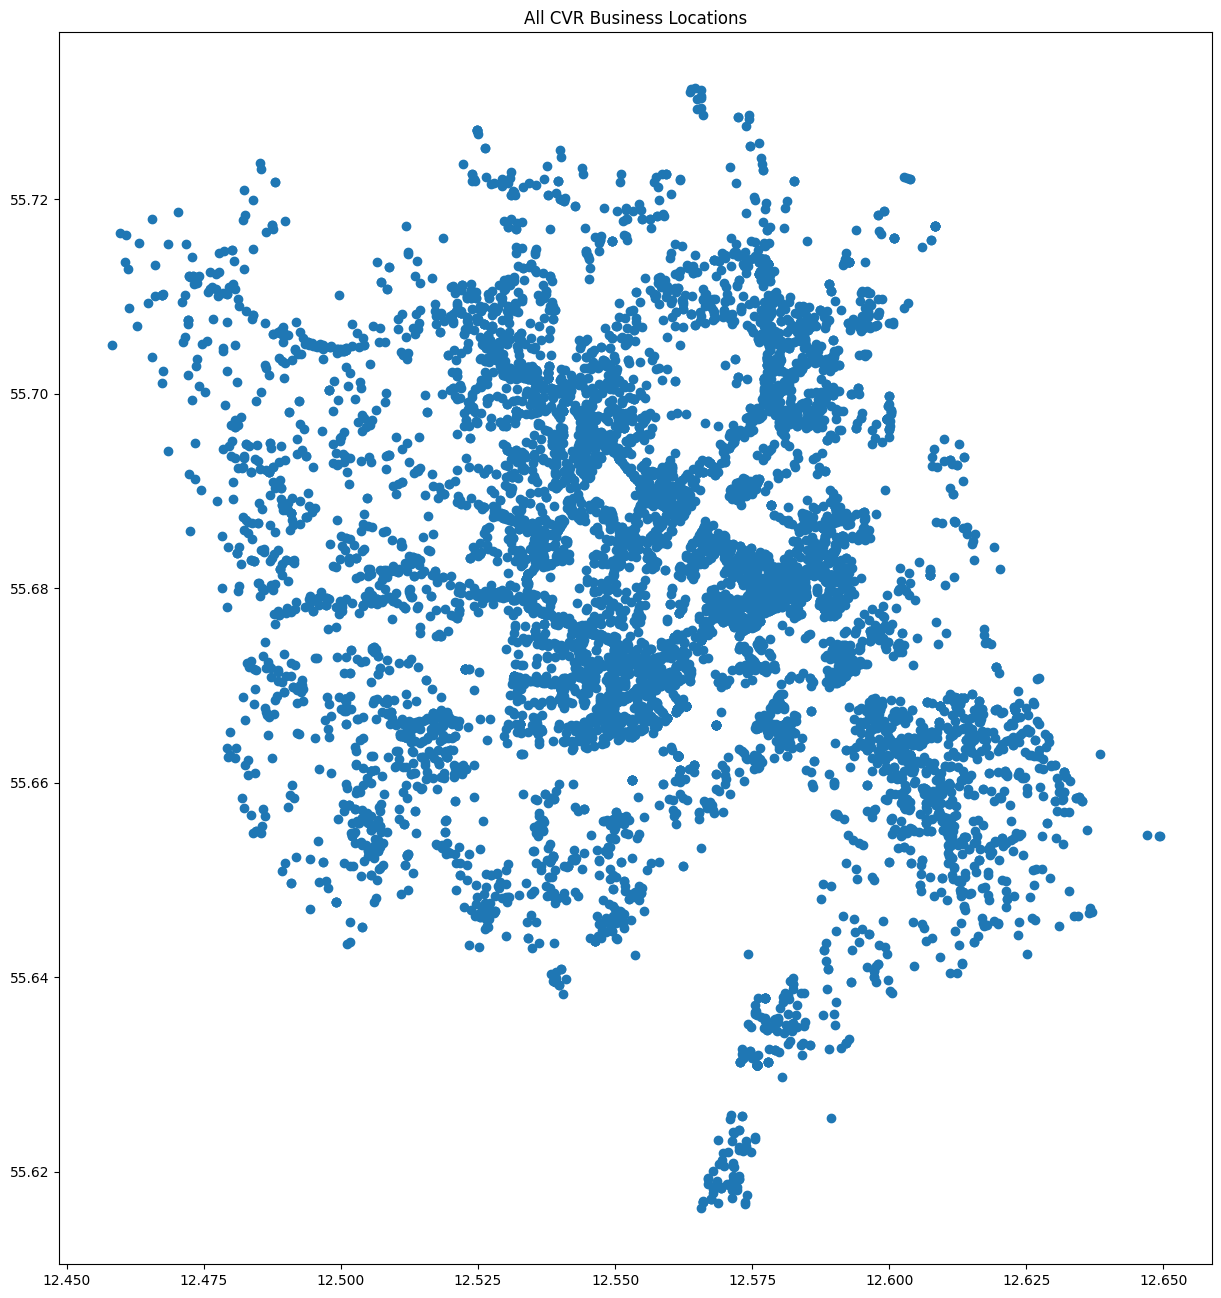

In [46]:
# Check and convert date columns
print("Date columns info:")
print(f"virksomhedStartdato - unique values: {cvr_gdf['virksomhedStartdato'].nunique()}")
print(f"virksomhedStartdato - null values: {cvr_gdf['virksomhedStartdato'].isna().sum()}")

# Convert date columns to datetime
cvr_gdf['virksomhedStartdato'] = pd.to_datetime(cvr_gdf['virksomhedStartdato'], errors='coerce')
cvr_gdf['virksomhedOphoersdato'] = pd.to_datetime(cvr_gdf['virksomhedOphoersdato'], errors='coerce')

# Extract year from start date
cvr_gdf['start_year'] = cvr_gdf['virksomhedStartdato'].dt.year
cvr_gdf['end_year'] = cvr_gdf['virksomhedOphoersdato'].dt.year

# Clamp start_year to 1987 for analysis purposes
cvr_gdf['start_year'] = cvr_gdf['start_year'].fillna(1987).astype(int)
cvr_gdf.loc[cvr_gdf['start_year'] < 1987, 'start_year'] = 1987

print(f"\nStart year range: {cvr_gdf['start_year'].min()} to {cvr_gdf['start_year'].max()}")
print(f"End year range: {cvr_gdf['end_year'].min()} to {cvr_gdf['end_year'].max()}")

# Plot all businesses
cvr_gdf.plot()
plt.title('All CVR Business Locations')
plt.show()

#### Reproject to UTM

Since we'll be using Euclidean distance calculations, we need to reproject from lat/lon (EPSG:4326) to UTM Zone 32 North (EPSG:25832):


In [47]:
# Check current CRS and reproject
print(f"Original CRS: {cvr_gdf.crs}")

# Reproject to UTM32N for distance calculations in meters
cvr_gdf = cvr_gdf.to_crs(epsg=25832)

print(f"Reprojected to: {cvr_gdf.crs}")
print(f"\nSample coordinates (UTM32N):")
print(cvr_gdf[['navn', 'geometry']].head())

Original CRS: EPSG:4326
Reprojected to: EPSG:25832

Sample coordinates (UTM32N):
                               navn                      geometry
0  THE AUSTRALIAN BAR KØBENHAVN ApS  POINT (724484.73 6176014.37)
1  THE AUSTRALIAN BAR KØBENHAVN ApS  POINT (724569.18 6175811.05)
2                  A/S PSE NR. 4938   POINT (722862.8 6175672.73)
3                     RUE VERTE A/S  POINT (725235.65 6176395.59)
4                CAB INN ESTATE A/S  POINT (724541.43 6175192.74)


Year range: 1987 to 2026
Active businesses in 2015: 2960
Active businesses in 2020: 4066


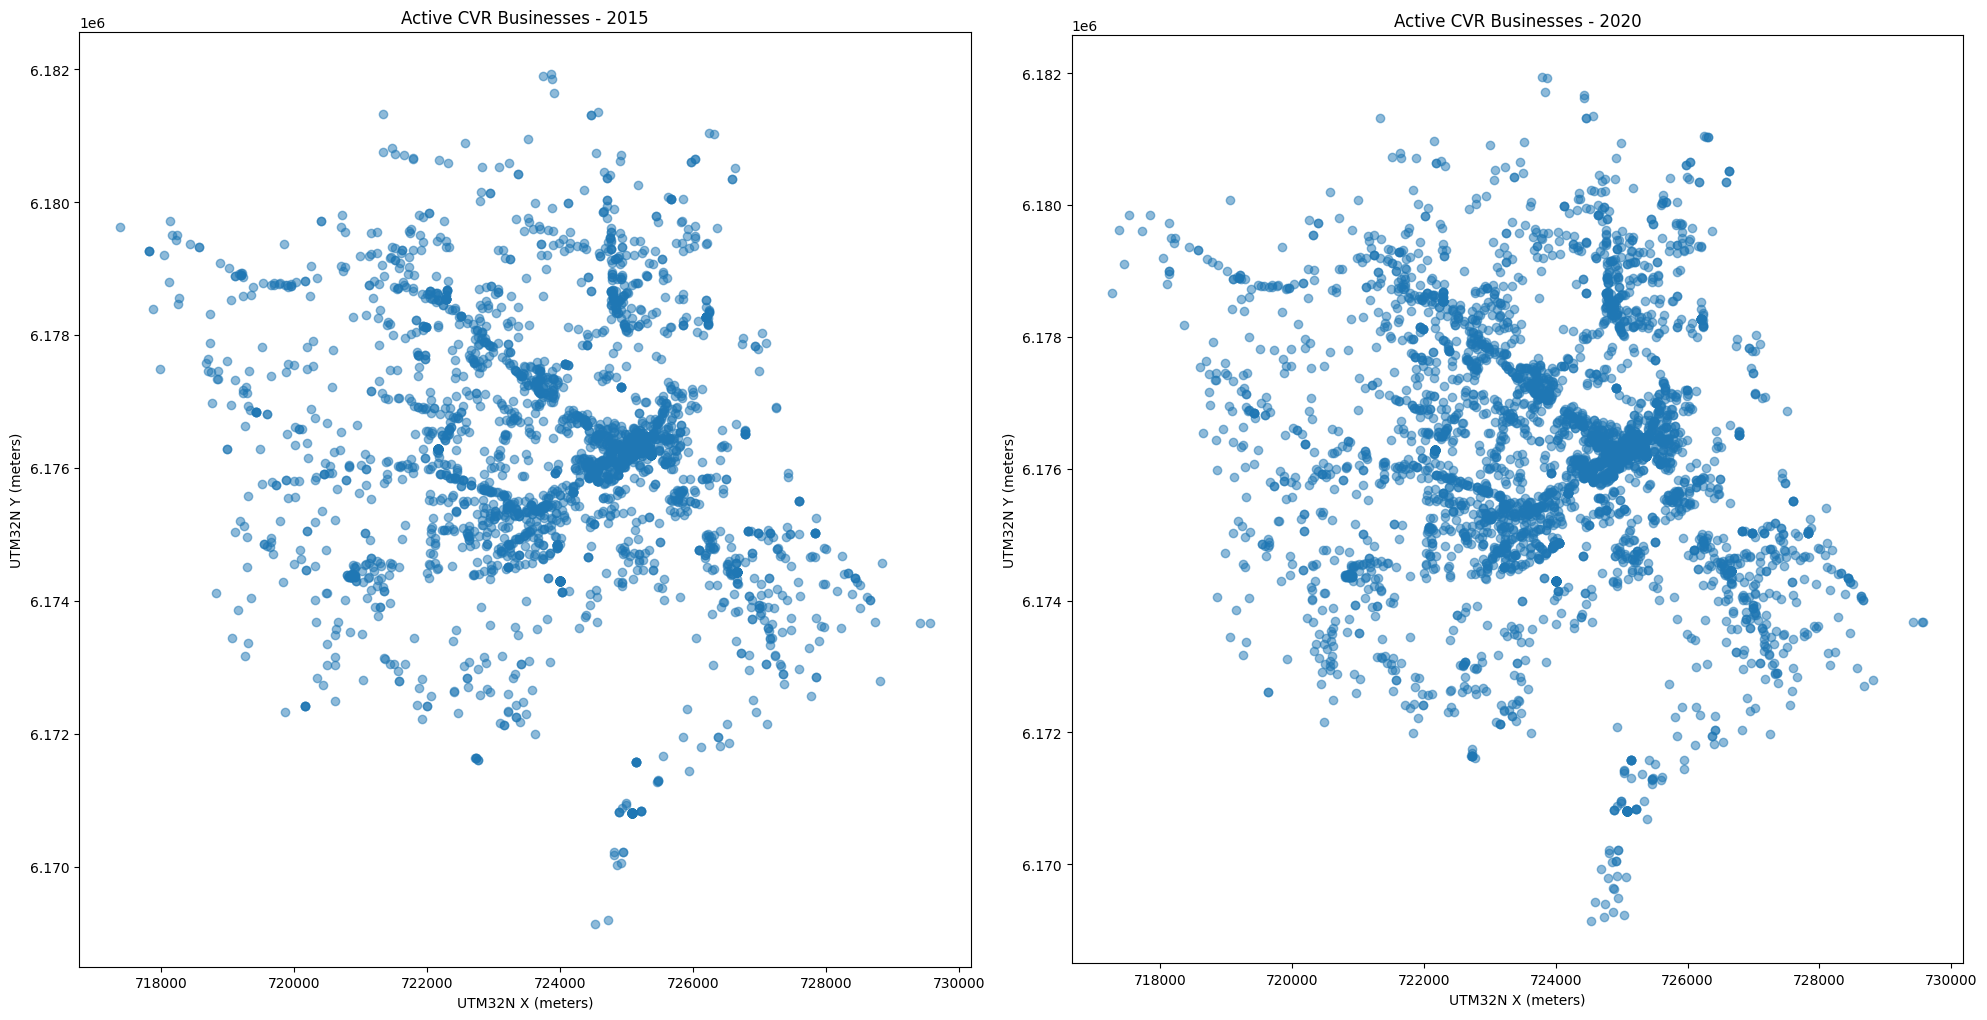

In [48]:
# Let's create temporal subsets for comparison
# We'll filter by time periods to analyze business patterns evolution

# Get the year range
year_min = cvr_gdf['start_year'].min()
year_max = cvr_gdf['start_year'].max()

print(f"Year range: {year_min} to {year_max}")

# Create a snapshot of active businesses in specific years
# Active = started before or in that year AND (no end date OR end date after that year)

def get_active_businesses(gdf, year):
    """Filter for businesses active in a given year"""
    active = gdf[(gdf['start_year'] <= year) & 
                 ((gdf['end_year'].isna()) | (gdf['end_year'] > year))]
    return active

# Create snapshots for recent years
cvr_2015 = get_active_businesses(cvr_gdf, 2015)
cvr_2020 = get_active_businesses(cvr_gdf, 2020)

print(f"Active businesses in 2015: {len(cvr_2015)}")
print(f"Active businesses in 2020: {len(cvr_2020)}")

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

cvr_2015.plot(ax=ax1, alpha=0.5)
ax1.set_title('Active CVR Businesses - 2015')
ax1.set_xlabel('UTM32N X (meters)')
ax1.set_ylabel('UTM32N Y (meters)')

cvr_2020.plot(ax=ax2, alpha=0.5)
ax2.set_title('Active CVR Businesses - 2020')
ax2.set_xlabel('UTM32N X (meters)')
ax2.set_ylabel('UTM32N Y (meters)')

plt.tight_layout()
plt.show()

### Filter by business type (optional)

We can filter by industry branch (branche_navn or branche_kode) to focus on specific sectors:


Total unique industries: 26

Top 20 industries by business count:
branche_navn
Tøjforretninger                                                                 1601
Billedkunstnerisk skaben                                                        1404
Detailhandel med tøj                                                             925
Udskænkning af alkoholiske drikkevarer                                           589
Detailhandel med drikkevarer                                                     558
Detailhandel med brød, konditori- og sukkervarer                                 444
Teater- og koncertproduktioner                                                   423
Detailhandel med brugte varer i forretninger                                     416
Detailhandel med andre fødevarer                                                 320
Detailhandel med brugte varer                                                    301
Anden kunstnerisk skaben                                               

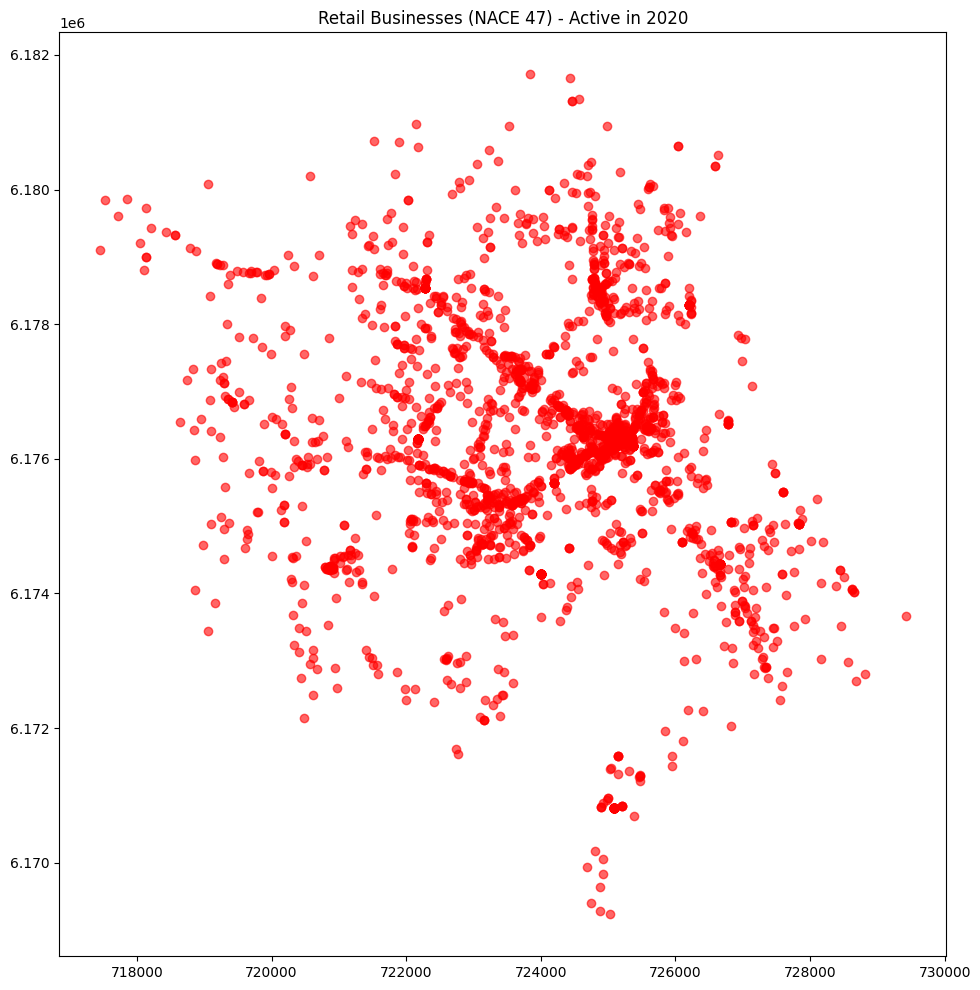

In [49]:
# Explore industry branches
print(f"Total unique industries: {cvr_gdf['branche_navn'].nunique()}")
print(f"\nTop 20 industries by business count:")
print(cvr_gdf['branche_navn'].value_counts().head(20))

# Optional: Filter to a specific industry
# Example: Retail trade (NACE code 47)
retail_2020 = cvr_2020[cvr_2020['branche_kode'].astype(str).str.startswith('47')]
print(f"\nRetail businesses in 2020: {len(retail_2020)}")

# Plot retail businesses
retail_2020.plot(figsize=(12, 12), alpha=0.6, color='red')
plt.title('Retail Businesses (NACE 47) - Active in 2020')
plt.show()

Mean centre 2015: POINT (723971.6795332411 6176132.906775528)
Mean centre 2020: POINT (723944.5490184125 6176157.201200181)
Copenhagen shapefile not found, plotting without boundary


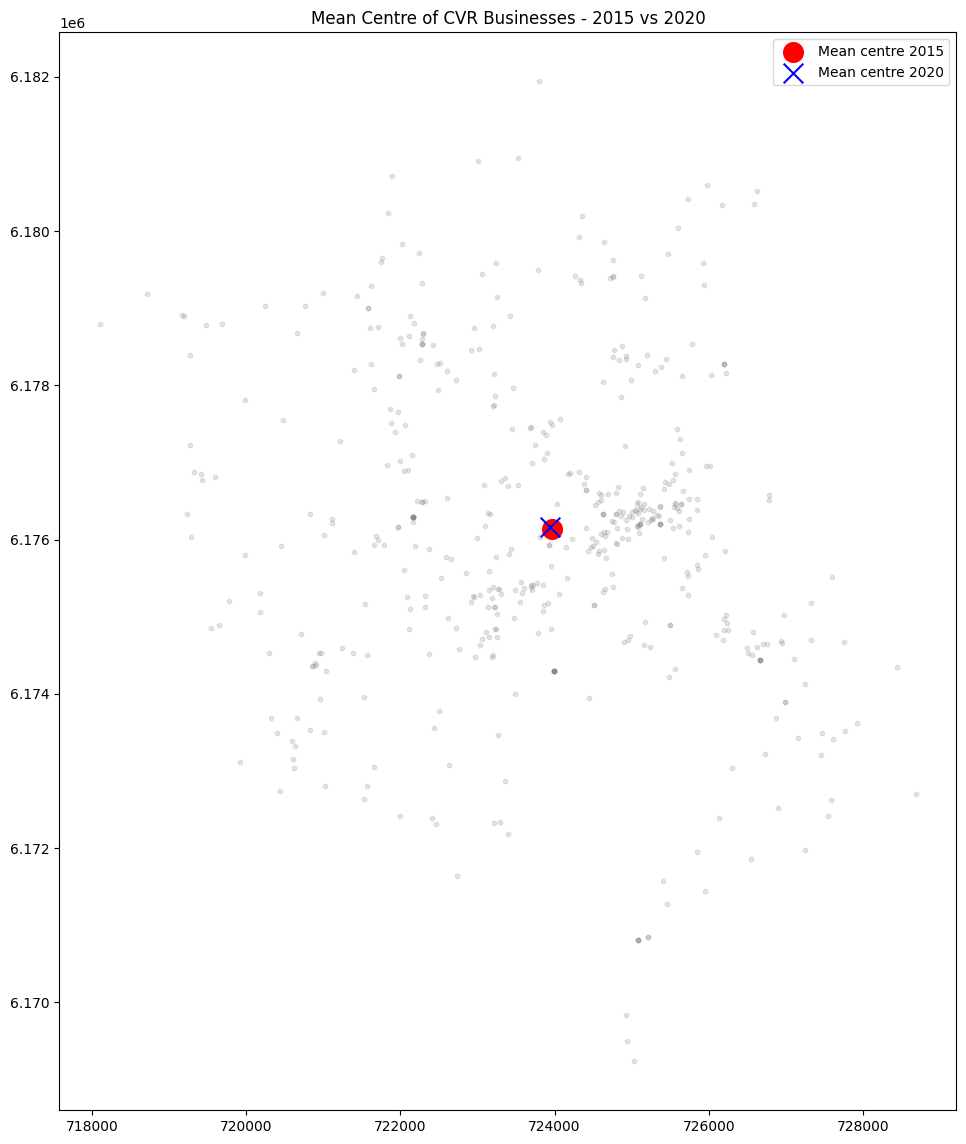

In [50]:
# Mean centre analysis
# Calculate the mean location (geographic center) of businesses in each year

mean_centre_2015 = Point((cvr_2015.geometry.x.mean(), cvr_2015.geometry.y.mean()))
mean_centre_2020 = Point((cvr_2020.geometry.x.mean(), cvr_2020.geometry.y.mean()))

print(f"Mean centre 2015: {mean_centre_2015}")
print(f"Mean centre 2020: {mean_centre_2020}")

# Convert to GeoDataFrames for plotting
mean_centre_2015_gdf = gpd.GeoDataFrame(crs='epsg:25832', geometry=[mean_centre_2015])
mean_centre_2020_gdf = gpd.GeoDataFrame(crs='epsg:25832', geometry=[mean_centre_2020])

# Plot with Copenhagen boundary (if available)
try:
    cph_shp = gpd.read_file('/Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/neighborhood_shapefile/neighborhoods_cph.shp')
    cph_shp = cph_shp.to_crs(epsg=25832)
    base = cph_shp.plot(color='white', edgecolor='black', figsize=(14, 14))
except:
    print("Copenhagen shapefile not found, plotting without boundary")
    fig, ax = plt.subplots(figsize=(14, 14))
    base = ax

# Plot mean centres
mean_centre_2015_gdf.plot(ax=base, marker='o', color='red', markersize=200, label='Mean centre 2015')
mean_centre_2020_gdf.plot(ax=base, marker='x', color='blue', markersize=200, label='Mean centre 2020')

# Plot some of the actual points for context
cvr_2020.sample(n=min(500, len(cvr_2020))).plot(ax=base, alpha=0.2, color='gray', markersize=10)

plt.legend()
plt.title('Mean Centre of CVR Businesses - 2015 vs 2020')
plt.show()

### Standard distance

The standard distance (or standard deviational ellipse) measures how spread out the businesses are from their mean centre:


Standard distance 2015: 2312.64 meters (2.31 km)
Standard distance 2020: 2346.73 meters (2.35 km)
Change: 1.47%


/var/folders/wb/v8kw8gx10fg848hdg_th7c400000gn/T/ipykernel_35268/3656092268.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(fontsize=12)
/var/folders/wb/v8kw8gx10fg848hdg_th7c400000gn/T/ipykernel_35268/3656092268.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


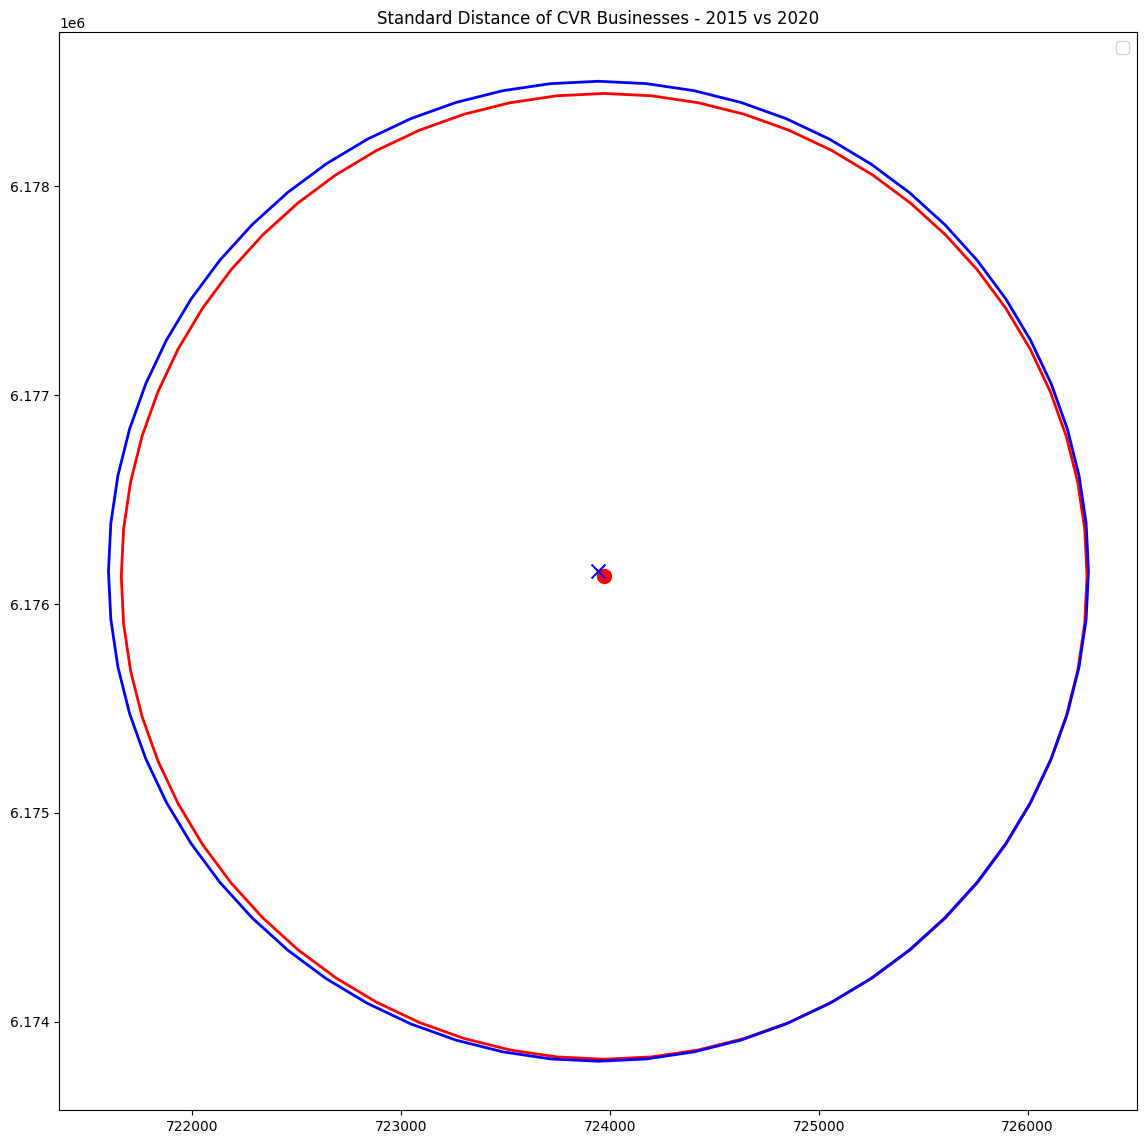

In [51]:
# Calculate standard distance for 2015 and 2020
sd_2015 = cvr_2015.geometry.distance(mean_centre_2015).mean()
sd_2020 = cvr_2020.geometry.distance(mean_centre_2020).mean()

print(f"Standard distance 2015: {sd_2015:.2f} meters ({sd_2015/1000:.2f} km)")
print(f"Standard distance 2020: {sd_2020:.2f} meters ({sd_2020/1000:.2f} km)")
print(f"Change: {((sd_2020 - sd_2015)/sd_2015)*100:.2f}%")

# Plot with standard distance buffers
try:
    base = cph_shp.plot(color='white', edgecolor='black', figsize=(14, 14))
except:
    fig, ax = plt.subplots(figsize=(14, 14))
    base = ax

# Plot mean centres and buffers
mean_centre_2015_gdf.plot(ax=base, marker='o', color='red', markersize=100)
mean_centre_2015_gdf.buffer(sd_2015).plot(ax=base, edgecolor='red', facecolor='none', linewidth=2, label=f'SD 2015: {sd_2015/1000:.1f}km')

mean_centre_2020_gdf.plot(ax=base, marker='x', color='blue', markersize=100)
mean_centre_2020_gdf.buffer(sd_2020).plot(ax=base, edgecolor='blue', facecolor='none', linewidth=2, label=f'SD 2020: {sd_2020/1000:.1f}km')

plt.legend(fontsize=12)
plt.title('Standard Distance of CVR Businesses - 2015 vs 2020')
plt.show()

### Business intensity over time

Calculate the number of businesses per square kilometer:


In [52]:
# Load Copenhagen boundary for area calculation
try:
    cph_mun = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'GIS_lag' / 'cph_mun.shp')
    cph_mun = cph_mun.to_crs(epsg=25832)
    cph_area_sqm = cph_mun.geometry.area.sum()
    cph_area_sqkm = cph_area_sqm / 1_000_000
    
    print(f"Copenhagen area: {cph_area_sqkm:.2f} km²")
    
    # Calculate intensity (businesses per km²)
    intensity_2015 = len(cvr_2015) / cph_area_sqkm
    intensity_2020 = len(cvr_2020) / cph_area_sqkm
    
    print(f"\nBusiness intensity 2015: {intensity_2015:.2f} businesses/km²")
    print(f"Business intensity 2020: {intensity_2020:.2f} businesses/km²")
    print(f"Change: {((intensity_2020 - intensity_2015)/intensity_2015)*100:.2f}%")
    
except Exception as e:
    print(f"Could not calculate area: {e}")
    intensity_2015 = len(cvr_2015)
    intensity_2020 = len(cvr_2020)
    print(f"\nTotal businesses 2015: {intensity_2015}")
    print(f"Total businesses 2020: {intensity_2020}")

Copenhagen area: 98.22 km²

Business intensity 2015: 30.14 businesses/km²
Business intensity 2020: 41.40 businesses/km²
Change: 37.36%


### 2D Histograms - Business Density Distribution

Visualize where businesses are concentrated:


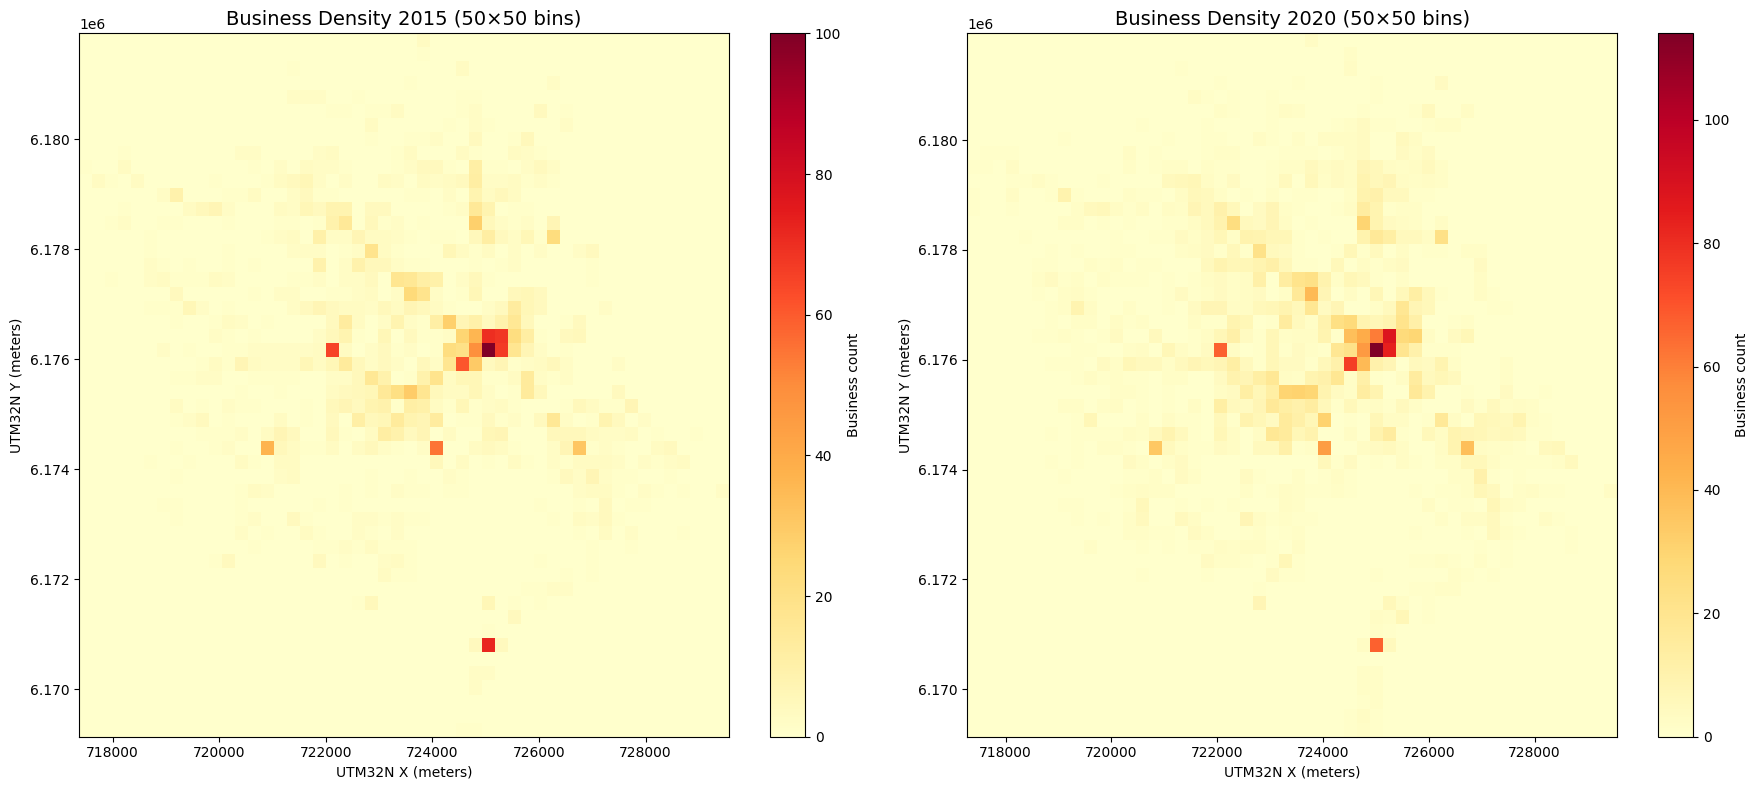

In [53]:
# 2D histograms for both years
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 2015
p1 = ax1.hist2d(cvr_2015.geometry.x, cvr_2015.geometry.y, bins=50, cmap='YlOrRd')
plt.colorbar(p1[3], ax=ax1, label='Business count')
ax1.set_title('Business Density 2015 (50×50 bins)', fontsize=14)
ax1.set_xlabel('UTM32N X (meters)')
ax1.set_ylabel('UTM32N Y (meters)')

# 2020
p2 = ax2.hist2d(cvr_2020.geometry.x, cvr_2020.geometry.y, bins=50, cmap='YlOrRd')
plt.colorbar(p2[3], ax=ax2, label='Business count')
ax2.set_title('Business Density 2020 (50×50 bins)', fontsize=14)
ax2.set_xlabel('UTM32N X (meters)')
ax2.set_ylabel('UTM32N Y (meters)')

plt.tight_layout()
plt.show()

### Kernel Density Estimation (KDE)

Create smooth density maps of business locations:


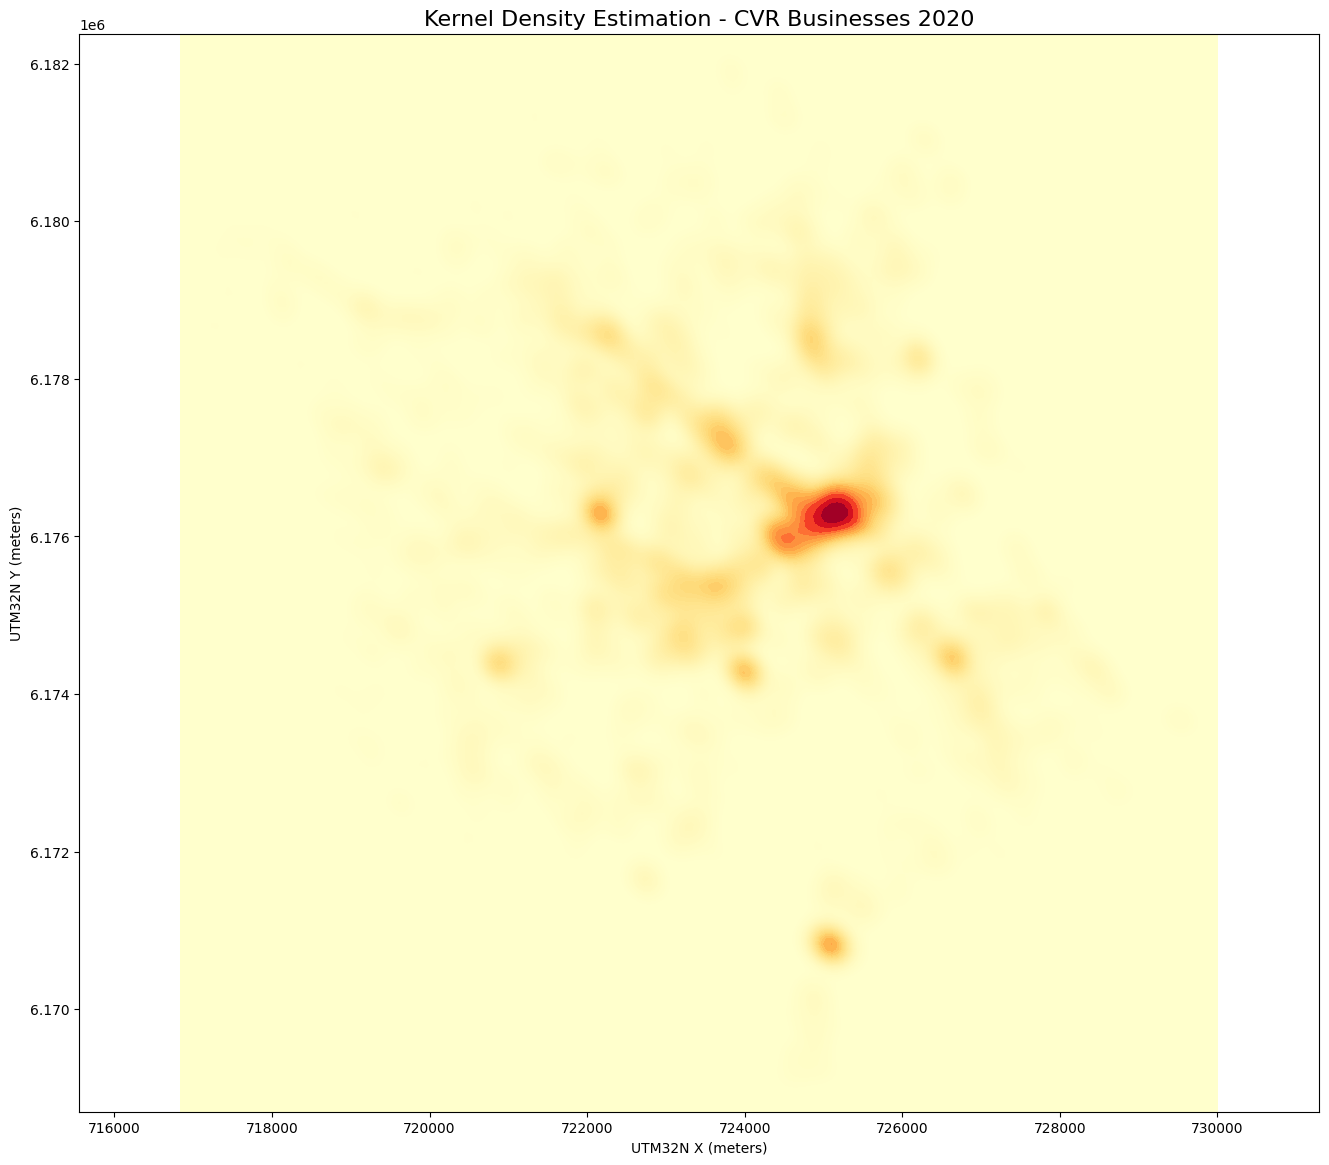

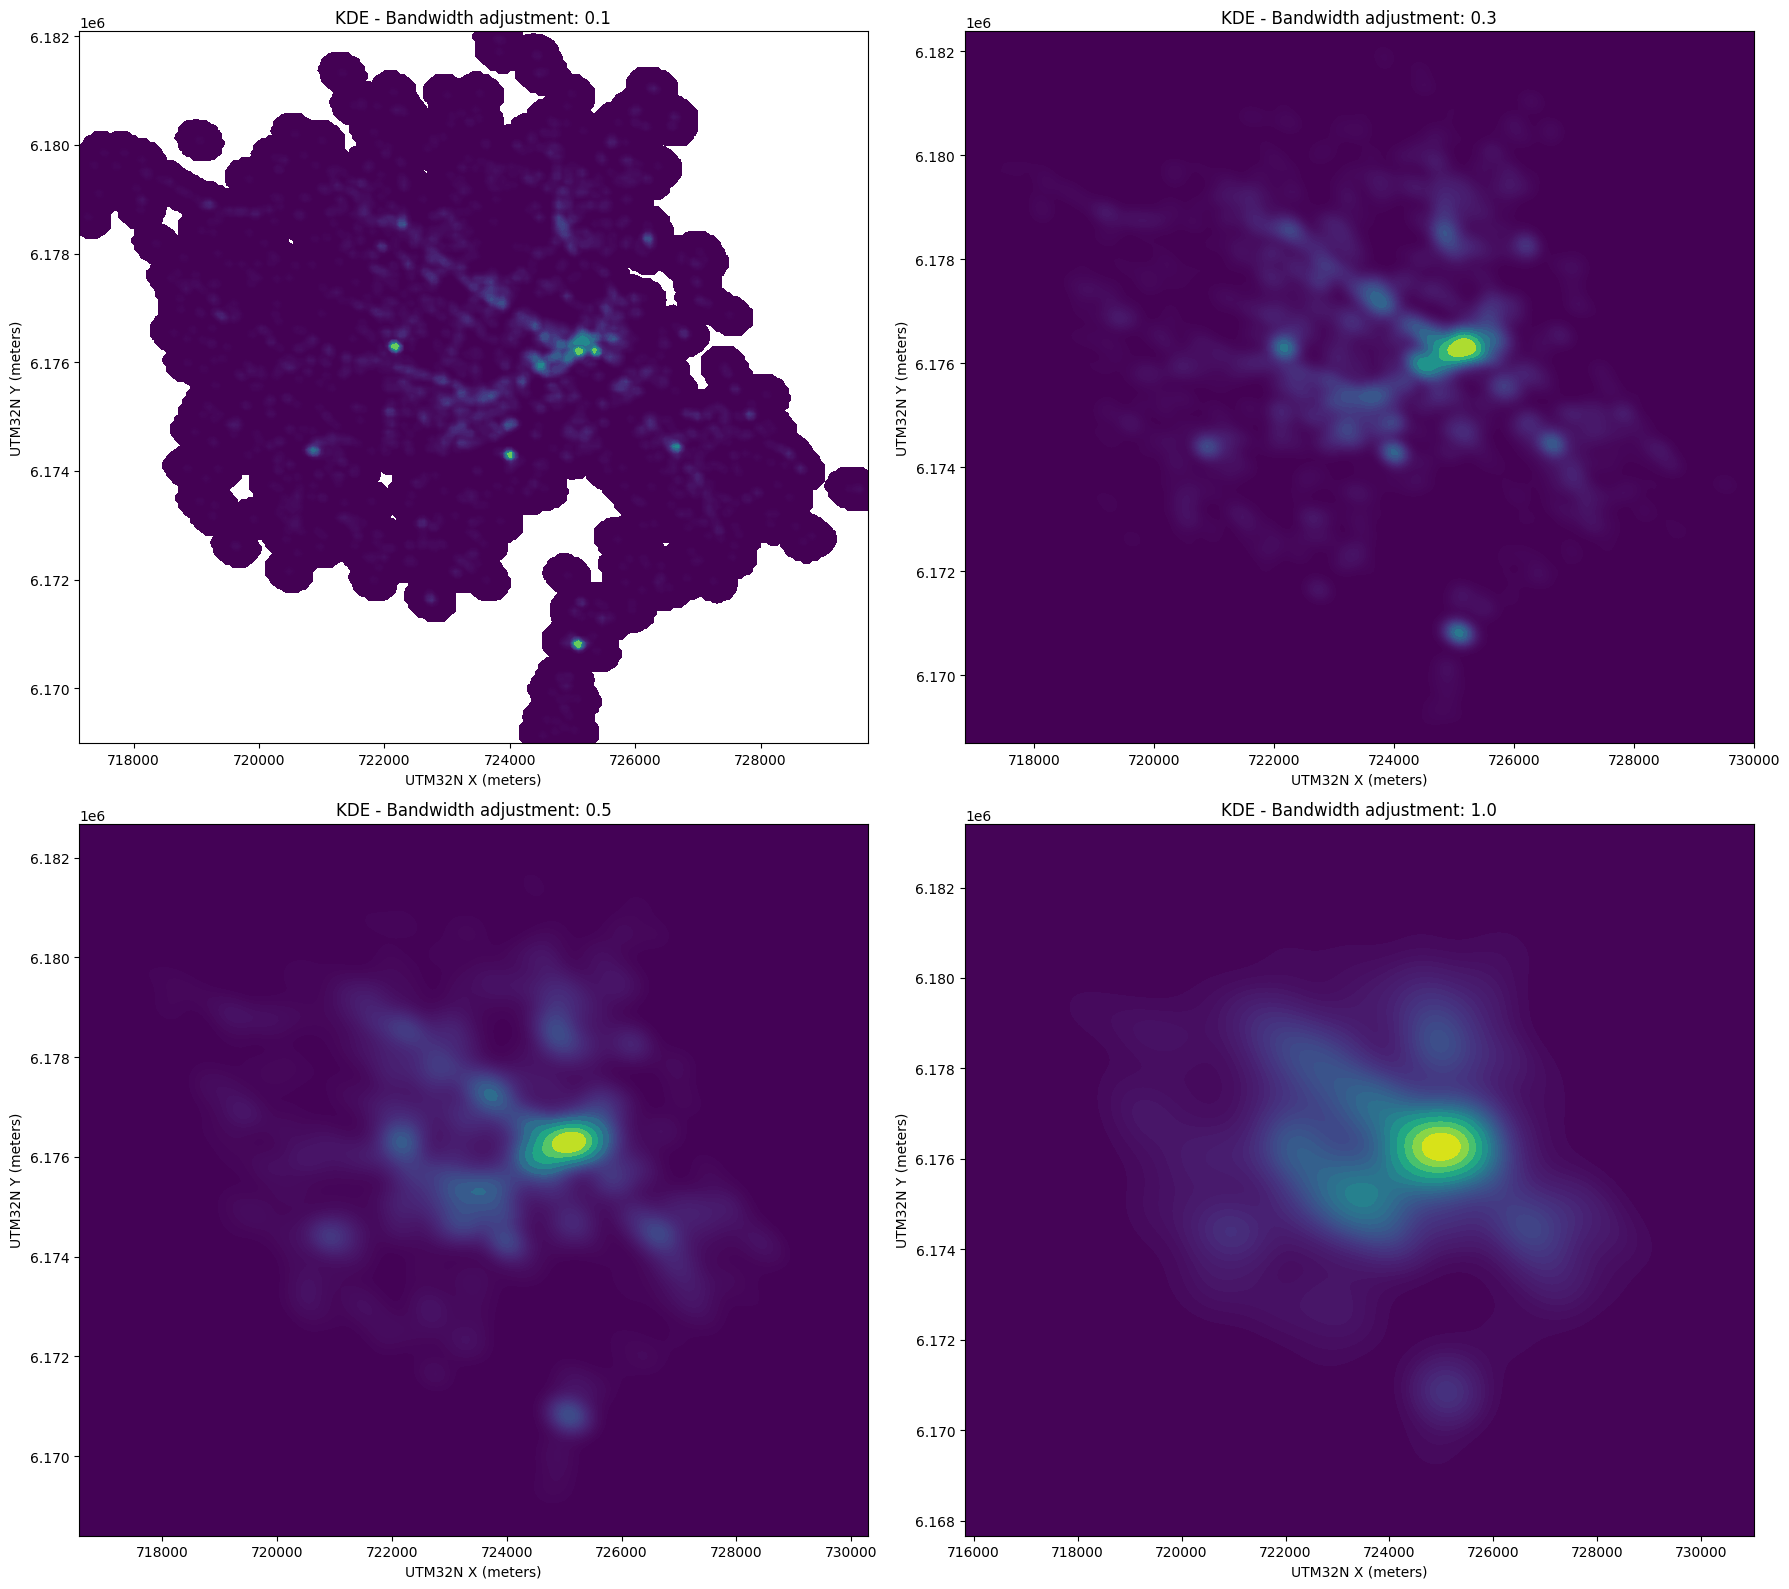

In [54]:
# Kernel Density Estimation for 2020 (most recent)
fig, ax = plt.subplots(figsize=(16, 14))

sns.kdeplot(
    x=cvr_2020.geometry.x,
    y=cvr_2020.geometry.y,
    fill=True,
    thresh=0,
    levels=50,
    cmap="YlOrRd",
    bw_adjust=0.3,
    ax=ax
)

# Overlay Copenhagen boundary if available
try:
    cph_shp.plot(edgecolor='grey', color="none", linewidth=1, ax=ax)
except:
    pass

ax.set_title('Kernel Density Estimation - CVR Businesses 2020', fontsize=16)
ax.set_xlabel('UTM32N X (meters)')
ax.set_ylabel('UTM32N Y (meters)')
plt.axis('equal')
plt.show()

# Try different bandwidth adjustments
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
bw_values = [0.1, 0.3, 0.5, 1.0]

for ax, bw in zip(axes.flat, bw_values):
    sns.kdeplot(
        x=cvr_2020.geometry.x,
        y=cvr_2020.geometry.y,
        fill=True,
        thresh=0,
        levels=30,
        cmap="viridis",
        bw_adjust=bw,
        ax=ax
    )
    ax.set_title(f'KDE - Bandwidth adjustment: {bw}', fontsize=12)
    ax.set_xlabel('UTM32N X (meters)')
    ax.set_ylabel('UTM32N Y (meters)')
    try:
        cph_shp.plot(edgecolor='black', color="none", linewidth=0.5, ax=ax)
    except:
        pass
    
plt.tight_layout()
plt.show()

Preparing point pattern analysis...
Number of businesses in 2020: 4066
Study window created from Copenhagen boundary


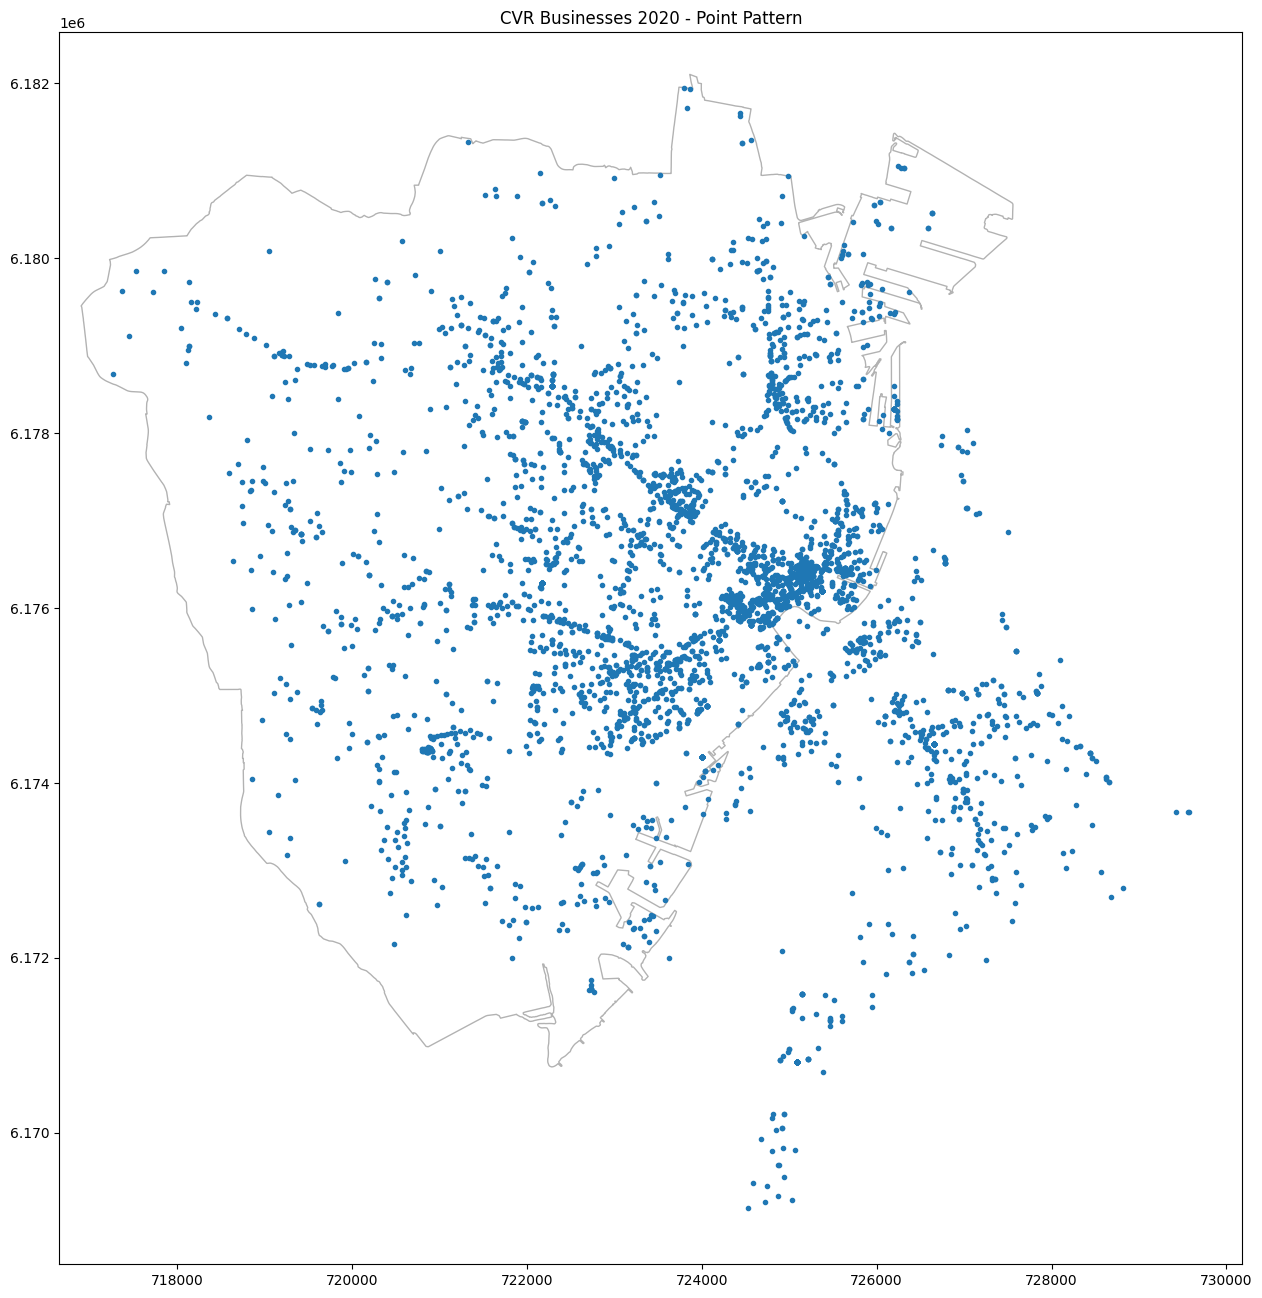

Point Pattern
4066 points
Bounding rectangle [(717272.5300734559,6169137.2048934065), (729567.84819928,6181942.550303278)]
Area of window: 66873290.65427505
Intensity estimate for window: 6.0801554106565715e-05
               x             y
0  724484.729881  6.176014e+06
1  724569.180001  6.175811e+06
2  722862.800213  6.175673e+06
3  725235.650199  6.176396e+06
4  720163.199783  6.178811e+06
None


In [55]:
# Prepare data for point pattern analysis
# Create PointPattern objects for pointpats library

from shapely.geometry import Polygon, MultiPolygon
from libpysal.cg import Polygon as LPSPolygon

print("Preparing point pattern analysis...")

# Get CVR points as numpy array
cvr_points_2020 = np.array(list(zip(cvr_2020.geometry.x, cvr_2020.geometry.y)))
print(f"Number of businesses in 2020: {len(cvr_points_2020)}")

# Create or load study window (Copenhagen boundary)
try:
    cph_geom = cph_mun.geometry.union_all()  # Dissolve all geometries
    
    # If MultiPolygon, keep the largest
    if isinstance(cph_geom, MultiPolygon):
        cph_geom = max(cph_geom.geoms, key=lambda g: g.area)
    
    # Convert to libpysal Polygon
    shell = list(cph_geom.exterior.coords)
    holes = [list(r.coords) for r in cph_geom.interiors]
    lps_poly = LPSPolygon(shell, holes)
    
    # Create pointpats Window
    cph_window = as_window(lps_poly)
    print(f"Study window created from Copenhagen boundary")
    
except Exception as e:
    print(f"Warning: Could not create window from shapefile: {e}")
    print("Creating rectangular window from data extent...")
    # Create bounding box window
    minx, miny, maxx, maxy = cvr_2020.geometry.total_bounds
    bbox_coords = [(minx, miny), (maxx, miny), (maxx, maxy), (minx, maxy), (minx, miny)]
    lps_poly = LPSPolygon(bbox_coords)
    cph_window = as_window(lps_poly)

# Create PointPattern
pp_2020 = PointPattern(points=cvr_points_2020, window=cph_window)
pp_2020.plot(window=True, title='CVR Businesses 2020 - Point Pattern')
plt.show()

print(pp_2020.summary())

### Quadrat Statistics

Test for spatial randomness using quadrat analysis. We divide the study area into a grid and compare observed counts with expected counts under Complete Spatial Randomness (CSR):


# Mean centre

In Geopandas, we can extract the x and y components of the coordinates like so:

Computing quadrat statistics (20×20 grid)...


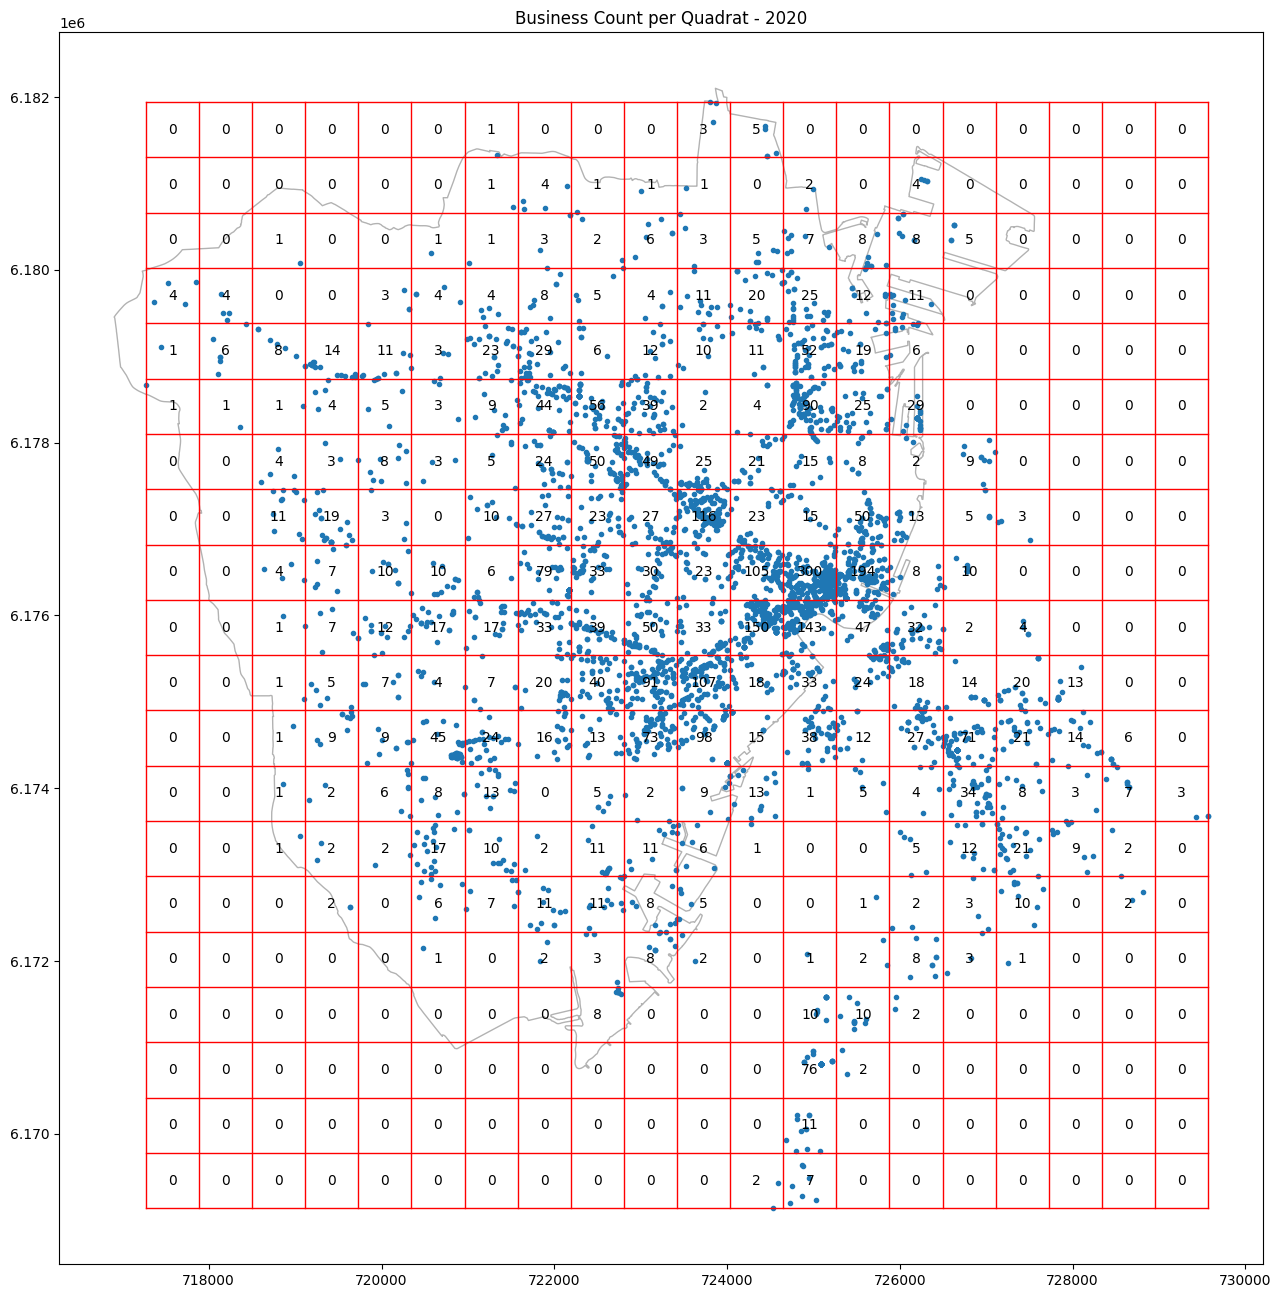

Quadrat statistics:
  Chi-square statistic: 26692.29
  (Visualization shows the counts in each quadrat cell above)


In [56]:
# Quadrat statistics: divide window into grid
print("Computing quadrat statistics (20×20 grid)...")

q_stat = qs.QStatistic(pp_2020, shape="rectangle", nx=20, ny=20)
q_stat.plot(title='Business Count per Quadrat - 2020')
plt.show()

print(f"Quadrat statistics:")
print(f"  Chi-square statistic: {q_stat.chi2:.2f}")
print(f"  (Visualization shows the counts in each quadrat cell above)")

So we can easily take the means and turn them into a new point:

In [57]:
# Compare with Complete Spatial Randomness (CSR)
print("Generating 10 random point patterns for comparison (this may take a moment)...")

csr_process = csr(pp_2020.window, pp_2020.n, 10, asPP=True)
print(f"Generated {len(csr_process.realizations)} random point patterns")

# Quadrat statistics with CSR comparison
print("\nComputing quadrat statistics with CSR comparison...")
q_stat_empirical = qs.QStatistic(pp_2020, shape="rectangle", nx=20, ny=20, realizations=csr_process)

# Statistical test
print(f"\nChi-square test results:")
print(f"  Observed chi-square: {q_stat_empirical.chi2:.2f}")
print(f"  Expected (from CSR): mean={np.mean(q_stat_empirical.chi2_realizations):.2f}, "
      f"std={np.std(q_stat_empirical.chi2_realizations):.2f}")
print(f"  P-value: {q_stat_empirical.chi2_pvalue:.6f}")

if q_stat_empirical.chi2_pvalue < 0.05:
    print("\n✓ Significant clustering detected (p < 0.05)")
    print("  Businesses are NOT randomly distributed - they show spatial clustering")
else:
    print("\n✗ No significant clustering (p ≥ 0.05)")
    print("  Businesses are approximately randomly distributed")

Generating 10 random point patterns for comparison (this may take a moment)...
Generated 10 random point patterns

Computing quadrat statistics with CSR comparison...

Chi-square test results:
  Observed chi-square: 26692.29
  Expected (from CSR): mean=2991.61, std=91.02
  P-value: 0.000000

✓ Significant clustering detected (p < 0.05)
  Businesses are NOT randomly distributed - they show spatial clustering
Generated 10 random point patterns

Computing quadrat statistics with CSR comparison...

Chi-square test results:
  Observed chi-square: 26692.29
  Expected (from CSR): mean=2991.61, std=91.02
  P-value: 0.000000

✓ Significant clustering detected (p < 0.05)
  Businesses are NOT randomly distributed - they show spatial clustering


### Nearest Neighbor Analysis

Analyze the average distance between nearest neighbors:


In [58]:
# Nearest Neighbor Distance (NND) analysis
print("Computing nearest neighbor distances...")

Do = pp_2020.mean_nnd  # Observed mean NND
De = csr(pp_2020.window, pp_2020.n, 1, asPP=True).realizations[0].mean_nnd  # Expected NND under CSR

nnd_ratio = Do / De

print(f"\nNearest Neighbor Analysis:")
print(f"  Observed mean NND (Do): {Do:.2f} meters ({Do/1000:.3f} km)")
print(f"  Expected mean NND (De): {De:.2f} meters ({De/1000:.3f} km)")
print(f"  NND Ratio (Do/De): {nnd_ratio:.3f}")
print(f"\nInterpretation:")
if nnd_ratio < 1:
    print(f"  → Values < 1.0 indicate CLUSTERING")
    print(f"  → Businesses are closer together than random (more clustered)")
elif nnd_ratio > 1:
    print(f"  → Values > 1.0 indicate DISPERSION")
    print(f"  → Businesses are farther apart than random (more spread out)")
else:
    print(f"  → Value ≈ 1.0 indicates RANDOM distribution")

Computing nearest neighbor distances...

Nearest Neighbor Analysis:
  Observed mean NND (Do): 37.79 meters (0.038 km)
  Expected mean NND (De): 64.85 meters (0.065 km)
  NND Ratio (Do/De): 0.583

Interpretation:
  → Values < 1.0 indicate CLUSTERING
  → Businesses are closer together than random (more clustered)

Nearest Neighbor Analysis:
  Observed mean NND (Do): 37.79 meters (0.038 km)
  Expected mean NND (De): 64.85 meters (0.065 km)
  NND Ratio (Do/De): 0.583

Interpretation:
  → Values < 1.0 indicate CLUSTERING
  → Businesses are closer together than random (more clustered)


### K-Function Analysis

The K-function measures spatial clustering at different distance scales:


Computing K-function (may take a moment)...


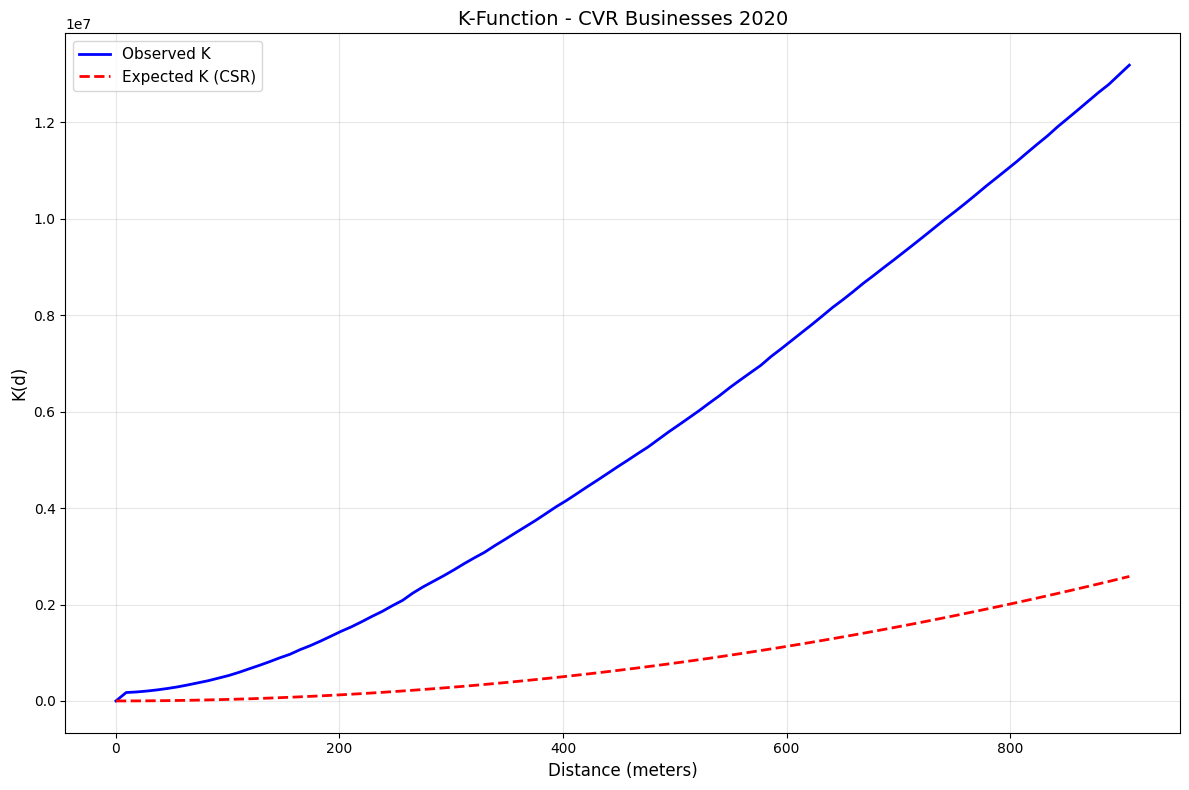

✓ K-function computed successfully

K-Function interpretation:
  Blue line = observed K-function
  Red dashed line = expected K-function under CSR (Complete Spatial Randomness)
  If blue line is ABOVE red: clustering at that distance
  If blue line is BELOW red: dispersion at that distance


In [59]:
# K-function
print("Computing K-function (may take a moment)...")

try:
    # Extract coordinates from point pattern
    coords = pp_2020.points
    
    # Compute K-function with support from 0 to max distance
    support = 100  # 100 equally spaced distance intervals
    kfunction_result = dst.k(coords, support=support)
    
    # Extract support and K values
    support_vals, k_vals = kfunction_result
    
    # Plot K-function
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(support_vals, k_vals, 'b-', linewidth=2, label='Observed K')
    
    # Add reference line for random distribution (Poisson)
    # For CSR: K(d) = π * d²
    poisson_k = np.pi * support_vals**2
    ax.plot(support_vals, poisson_k, 'r--', linewidth=2, label='Expected K (CSR)')
    
    ax.set_xlabel('Distance (meters)', fontsize=12)
    ax.set_ylabel('K(d)', fontsize=12)
    ax.set_title('K-Function - CVR Businesses 2020', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✓ K-function computed successfully")
    print("\nK-Function interpretation:")
    print("  Blue line = observed K-function")
    print("  Red dashed line = expected K-function under CSR (Complete Spatial Randomness)")
    print("  If blue line is ABOVE red: clustering at that distance")
    print("  If blue line is BELOW red: dispersion at that distance")
except Exception as e:
    print(f"Note: K-function computation failed: {e}")
    print("Skipping K-function analysis")

## Summary and Export Results

Save analysis results and create comparison visualizations:


In [60]:
# Create summary statistics dataframe
summary_data = {
    'Year': [2015, 2020],
    'Active Businesses': [len(cvr_2015), len(cvr_2020)],
    'Mean Centre X': [mean_centre_2015.x, mean_centre_2020.x],
    'Mean Centre Y': [mean_centre_2015.y, mean_centre_2020.y],
    'Standard Distance (m)': [sd_2015, sd_2020],
    'Standard Distance (km)': [sd_2015/1000, sd_2020/1000],
}

try:
    summary_data['Business Intensity (per km²)'] = [intensity_2015, intensity_2020]
except:
    pass

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("POINT PATTERN ANALYSIS SUMMARY - CVR BUSINESSES")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save summary
output_dir = Path('results/point_pattern_analysis')
output_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_dir / 'cvr_summary_statistics.csv', index=False)
print(f"\n✓ Summary saved to: {output_dir / 'cvr_summary_statistics.csv'}")


POINT PATTERN ANALYSIS SUMMARY - CVR BUSINESSES
 Year  Active Businesses  Mean Centre X  Mean Centre Y  Standard Distance (m)  Standard Distance (km)  Business Intensity (per km²)
 2015               2960  723971.679533   6.176133e+06            2312.635785                2.312636                     30.135577
 2020               4066  723944.549018   6.176157e+06            2346.727541                2.346728                     41.395695

✓ Summary saved to: results/point_pattern_analysis/cvr_summary_statistics.csv


## Analysis by Industry Sector

Perform point pattern analysis on specific business sectors:



SPATIAL DISTRIBUTION BY INDUSTRY SECTOR - 2020
                           Business Count         Mean X        Mean Y  Std Distance (m)
Retail Trade                       2408.0  724016.717470  6.176115e+06       2333.596051
Food and Beverage Service           547.0  724111.966576  6.176266e+06       2031.566026

✓ Sector analysis saved to: results/point_pattern_analysis/cvr_sector_analysis.csv


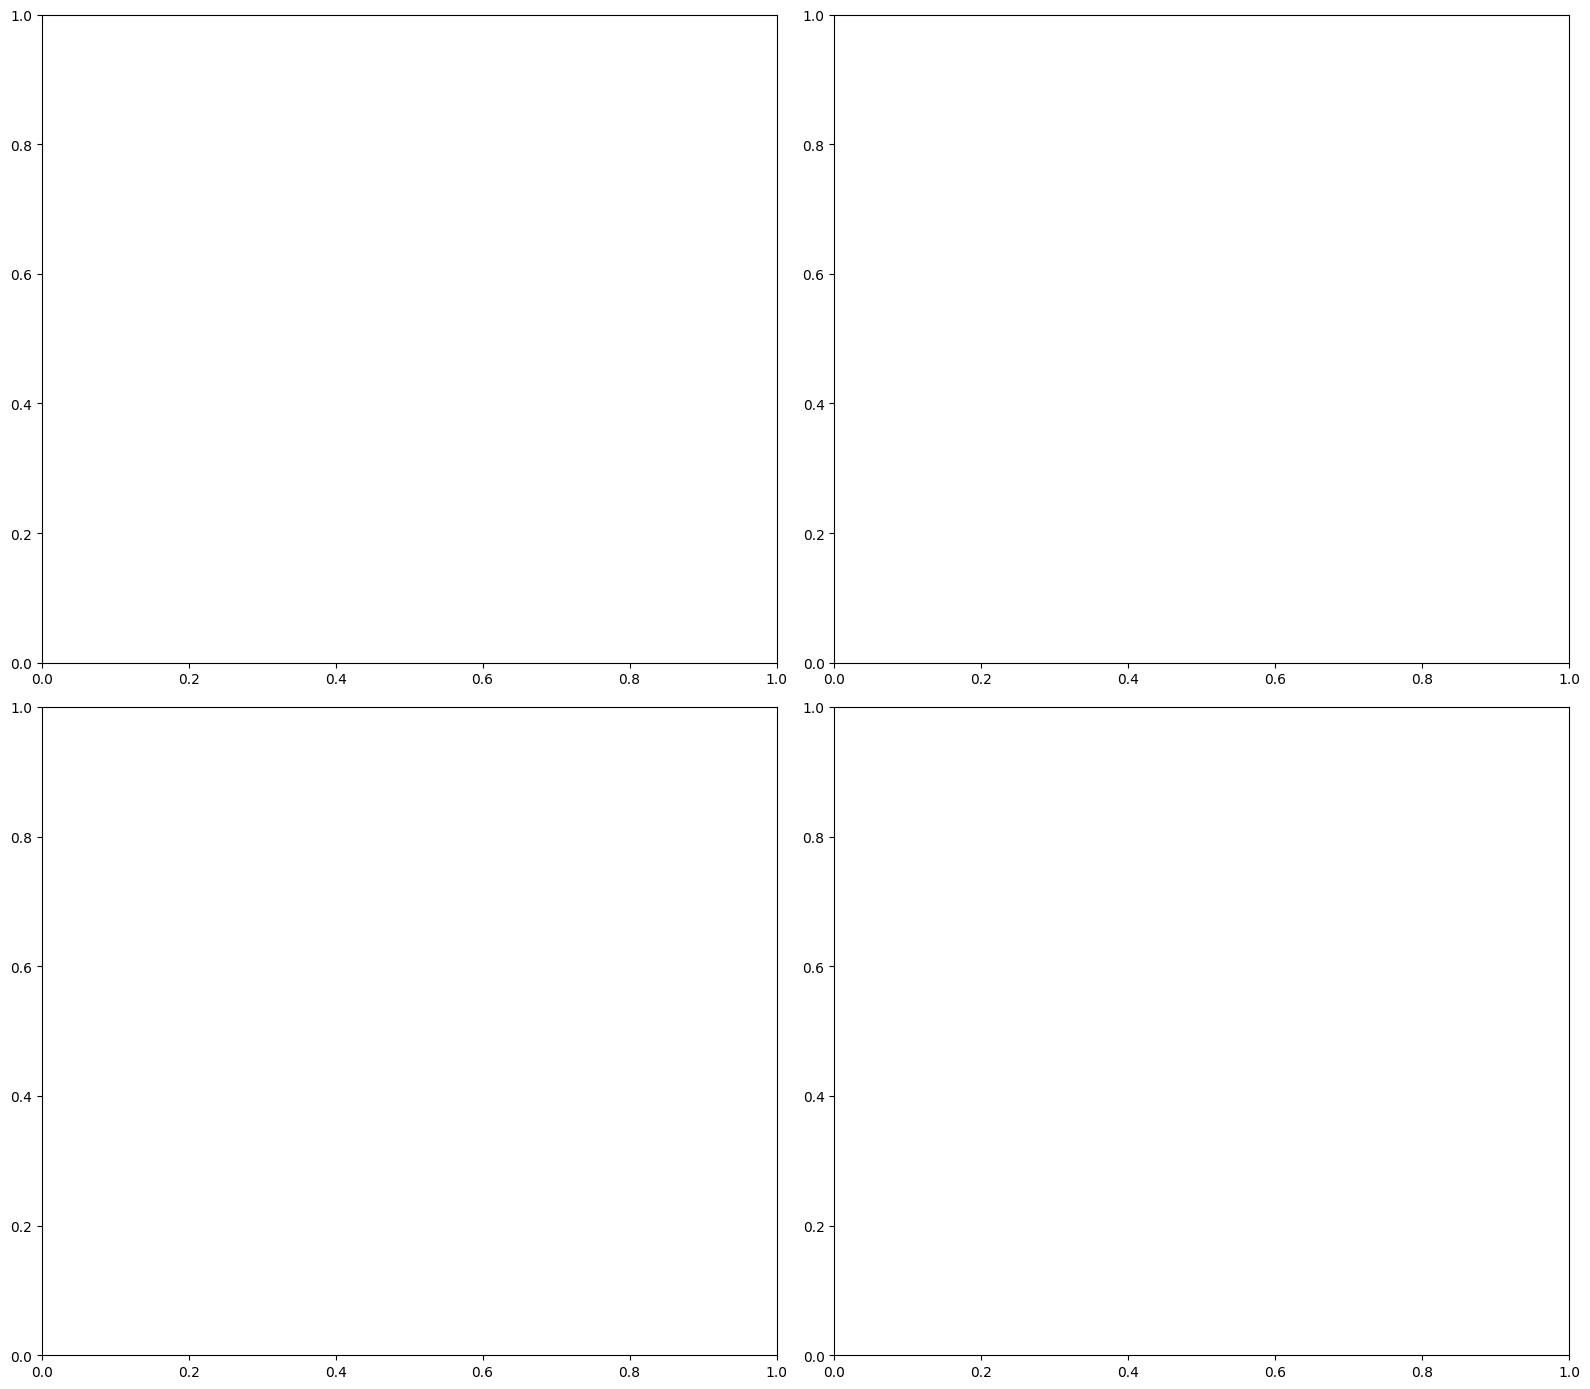

In [61]:
# Analyze specific sectors
# Select a major industry group for analysis
# NACE codes: 47=Retail, 45=Vehicles, 55=Accommodation, 56=Food/Beverage

sectors_to_analyze = {
    '47': 'Retail Trade',
    '56': 'Food and Beverage Service',
    '68': 'Real Estate',
    '62': 'IT Services'
}

sector_results = {}

for nace_code, sector_name in sectors_to_analyze.items():
    # Filter for this sector in 2020
    sector_data = cvr_2020[cvr_2020['branche_kode'].astype(str).str.startswith(nace_code)]
    
    if len(sector_data) > 10:  # Only analyze if enough data points
        mean_centre_sector = Point((sector_data.geometry.x.mean(), sector_data.geometry.y.mean()))
        sd_sector = sector_data.geometry.distance(mean_centre_sector).mean()
        
        sector_results[sector_name] = {
            'count': len(sector_data),
            'mean_centre_x': mean_centre_sector.x,
            'mean_centre_y': mean_centre_sector.y,
            'std_distance_m': sd_sector,
        }

# Create comparison table
if sector_results:
    sector_df = pd.DataFrame(sector_results).T
    sector_df.columns = ['Business Count', 'Mean X', 'Mean Y', 'Std Distance (m)']
    
    print("\n" + "="*80)
    print("SPATIAL DISTRIBUTION BY INDUSTRY SECTOR - 2020")
    print("="*80)
    print(sector_df.to_string())
    print("="*80)
    
    # Save sector analysis
    sector_df.to_csv(output_dir / 'cvr_sector_analysis.csv')
    print(f"\n✓ Sector analysis saved to: {output_dir / 'cvr_sector_analysis.csv'}")
    
    # Visualize sectors
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for ax, (sector_name, nace_code) in zip(axes, sectors_to_analyze.items()):
        sector_data = cvr_2020[cvr_2020['branche_kode'].astype(str).str.startswith(nace_code)]
        
        if len(sector_data) > 10:
            sector_data.plot(ax=ax, alpha=0.6, markersize=30)
            try:
                cph_shp.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.5)
            except:
                pass
            ax.set_title(f'{sector_name} ({len(sector_data)} businesses)', fontsize=12)
            ax.set_xlabel('UTM32N X')
            ax.set_ylabel('UTM32N Y')
    
    plt.tight_layout()
    plt.show()

## Temporal Analysis

Analyze how business distribution evolved over time:



TEMPORAL EVOLUTION OF BUSINESS DISTRIBUTION
 Year  Active Businesses        Mean X       Mean Y  Std Distance (m)
 1987                880 724015.838612 6.175935e+06       2164.458227
 1988                900 724014.350182 6.175933e+06       2165.120233
 1989                921 724001.707483 6.175942e+06       2159.797314
 1990                969 724031.566951 6.175942e+06       2151.024142
 1991                983 724013.683729 6.175955e+06       2160.843082
 1992                995 724012.571574 6.175969e+06       2166.885862
 1993               1019 724010.317672 6.175989e+06       2161.238051
 1994               1043 724007.268742 6.175994e+06       2156.825192
 1995               1073 723988.244351 6.176034e+06       2189.893772
 1996               1095 723970.277997 6.176044e+06       2193.059726
 1997               1145 723967.453135 6.176047e+06       2211.060191
 1998               1199 723952.016661 6.176069e+06       2223.856642
 1999               1245 723961.720761 6.1760

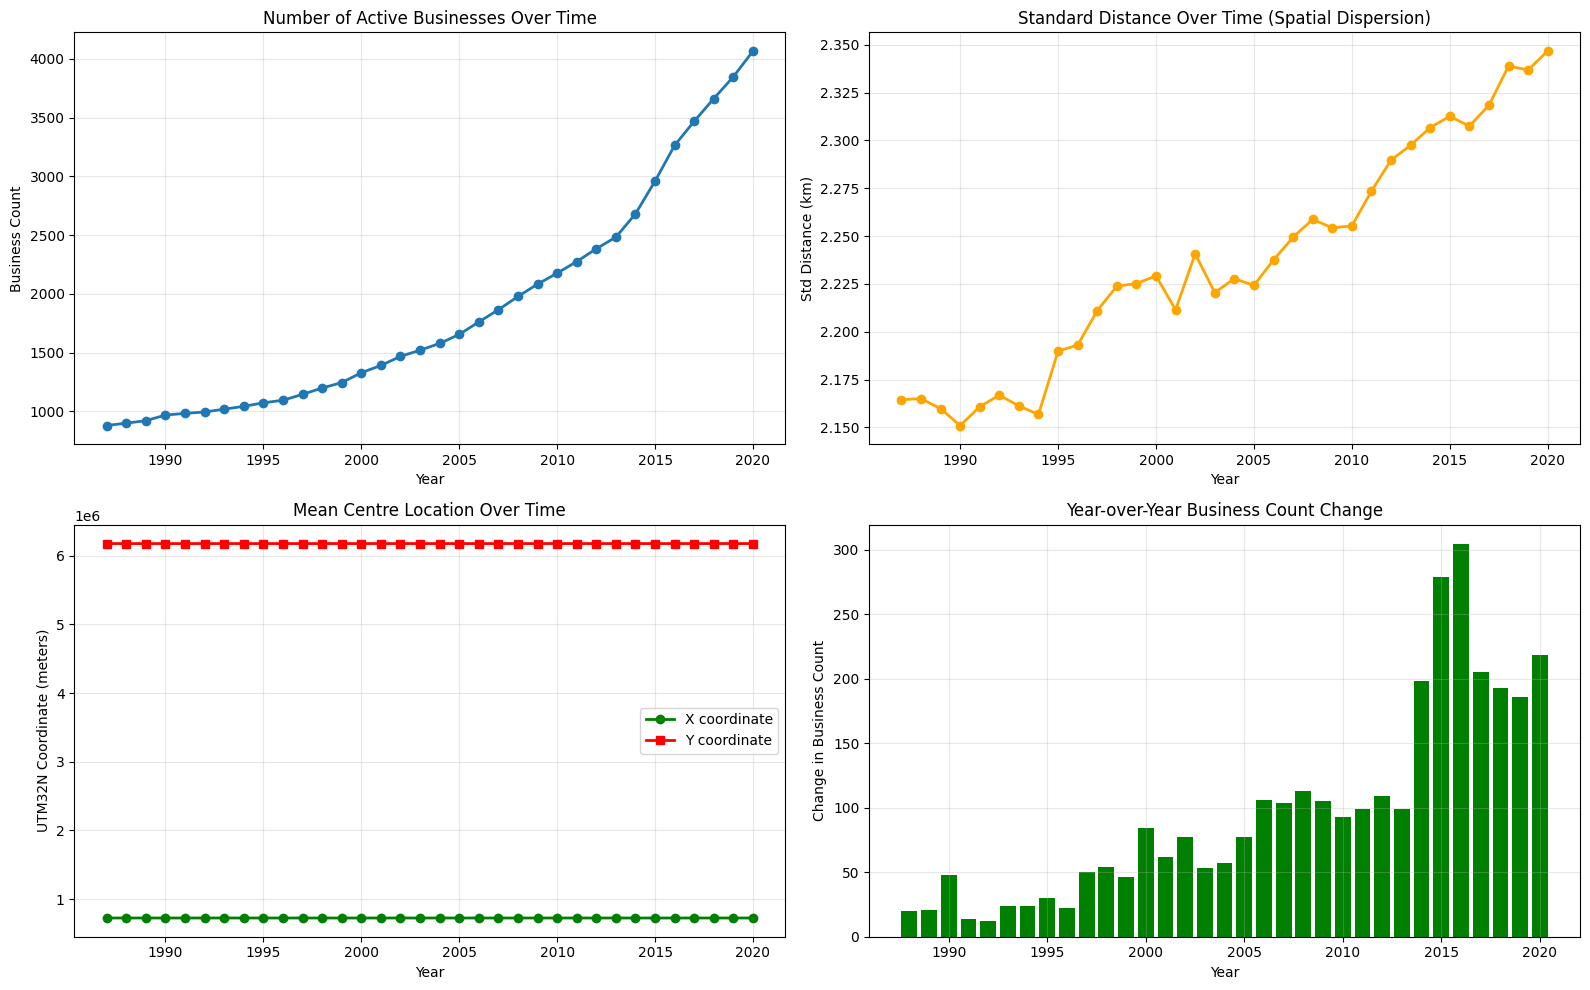

In [62]:
# Temporal evolution analysis
years_to_analyze = list(range(1987, 2021))
temporal_stats = []

for year in years_to_analyze:
    year_data = get_active_businesses(cvr_gdf, year)
    
    if len(year_data) > 50:  # Only if enough data
        mean_centre_year = Point((year_data.geometry.x.mean(), year_data.geometry.y.mean()))
        sd_year = year_data.geometry.distance(mean_centre_year).mean()
        
        temporal_stats.append({
            'Year': year,
            'Active Businesses': len(year_data),
            'Mean X': mean_centre_year.x,
            'Mean Y': mean_centre_year.y,
            'Std Distance (m)': sd_year,
        })

temporal_df = pd.DataFrame(temporal_stats)

print("\n" + "="*80)
print("TEMPORAL EVOLUTION OF BUSINESS DISTRIBUTION")
print("="*80)
print(temporal_df.to_string(index=False))
print("="*80)

# Save temporal data
temporal_df.to_csv(output_dir / 'cvr_temporal_evolution.csv', index=False)

# Plot trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(temporal_df['Year'], temporal_df['Active Businesses'], marker='o', linewidth=2)
axes[0, 0].set_title('Number of Active Businesses Over Time')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Business Count')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(temporal_df['Year'], temporal_df['Std Distance (m)'] / 1000, marker='o', linewidth=2, color='orange')
axes[0, 1].set_title('Standard Distance Over Time (Spatial Dispersion)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Std Distance (km)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(temporal_df['Year'], temporal_df['Mean X'], marker='o', linewidth=2, color='green', label='X coordinate')
axes[1, 0].plot(temporal_df['Year'], temporal_df['Mean Y'], marker='s', linewidth=2, color='red', label='Y coordinate')
axes[1, 0].set_title('Mean Centre Location Over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('UTM32N Coordinate (meters)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Year-over-year change
temporal_df['YoY Change'] = temporal_df['Active Businesses'].diff()
axes[1, 1].bar(temporal_df['Year'][1:], temporal_df['YoY Change'][1:], color=['green' if x > 0 else 'red' for x in temporal_df['YoY Change'][1:]])
axes[1, 1].set_title('Year-over-Year Business Count Change')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Change in Business Count')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## The End

This analysis demonstrates key point pattern analysis methods applied to CVR business data:

**Key Findings:**
- **Mean Centre & Standard Distance**: Track how businesses cluster around the city center
- **Quadrat Statistics**: Test whether businesses are randomly distributed
- **Nearest Neighbor Analysis**: Quantify clustering vs. dispersion
- **K-Function**: Identify clustering patterns at different spatial scales
- **Temporal Evolution**: Monitor how business distribution changes over time
- **Sectoral Patterns**: Understand geographic preferences by industry

**Next Steps:**
- Compare different time periods in detail
- Analyze specific industry sectors more deeply
- Overlay with gentrification indicators
- Create density surfaces for mapping
